In [1]:
# Figure 1: composition (Claim 1). Where the folding/QC census genes fall among the
# 61 high-confidence ATFS-1 targets, on both ranking metrics, and what the rest of
# the regulon actually is.
#
# Reads only from results/ - every number here was already computed and validated in
# census.ipynb, binding.ipynb, and table_s2.ipynb. This notebook draws; it does not
# derive.
import os
if os.path.basename(os.getcwd()) == "scripts":
    os.chdir("..")
import sys
sys.path.insert(0, "scripts")

import pandas as pd
import matplotlib.pyplot as plt
from figure_style import (BLUE, ORANGE, GREEN, GREY, INK, FULL_W,
                          figure_label, save)

regulon = pd.read_csv("results/regulon_61.csv")
reference = pd.read_csv("results/reference_genes.csv")
if len(regulon) != 61:
    raise RuntimeError(f"results/regulon_61.csv has {len(regulon)} rows, expected 61.")

STRICT_CENSUS = {"dnj-10", "ymel-1"}
PERMISSIVE_ONLY = {"prx-19", "cbp-3", "tspo-1"}
regulon["strict"] = regulon["public_name"].isin(STRICT_CENSUS)
regulon["permissive"] = regulon["public_name"].isin(PERMISSIVE_ONLY)

hsp6 = reference[reference["public_name"] == "hsp-6"].iloc[0]

# Re-validate the numbers this figure depends on before drawing anything - reading a
# stale results/ file would otherwise fail silently as a plausible-looking figure.
CHECKS = [
    ("dnj-10 rank_score", int(regulon.loc[regulon.public_name == "dnj-10", "rank_score"].iloc[0]), 45),
    ("dnj-10 rank_var",   int(regulon.loc[regulon.public_name == "dnj-10", "rank_var"].iloc[0]), 23),
    ("ymel-1 rank_score", int(regulon.loc[regulon.public_name == "ymel-1", "rank_score"].iloc[0]), 61),
    ("ymel-1 rank_var",   int(regulon.loc[regulon.public_name == "ymel-1", "rank_var"].iloc[0]), 58),
    ("hsp-6 inserted rank_score", int(hsp6["rank_score_inserted"]), 43),
    ("hsp-6 inserted rank_var",   int(hsp6["rank_var_inserted"]), 29),
    ("strict census count", int(regulon["strict"].sum()), 2),
    ("permissive-only count", int(regulon["permissive"].sum()), 3),
]
for label, got, expected in CHECKS:
    if got != expected:
        raise RuntimeError(f"{label}: got {got}, expected {expected} - results/ is stale, do not plot.")
print("All values validated against gate_decisions.md. Proceeding to draw.")

All values validated against gate_decisions.md. Proceeding to draw.


Saved figures/figure1_composition.{pdf,svg,png}


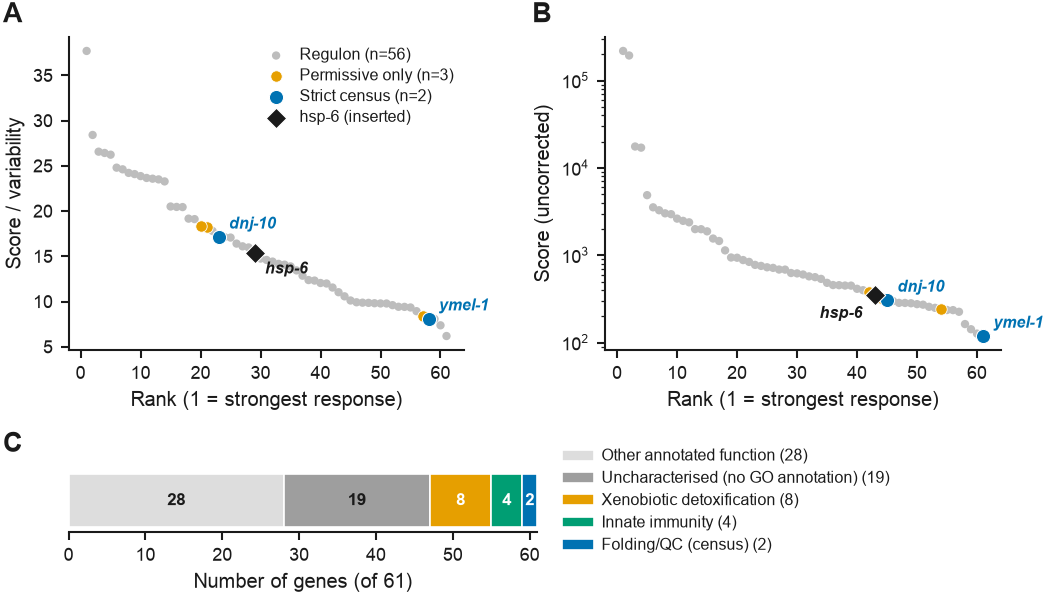


Reported separately, not as a bar segment: 28 of 61 (45.9%) carry no gene symbol.
That is a different axis from GO annotation status (see table_s2.ipynb) and must
not be merged with the category breakdown above.


In [2]:
# One figure, three panels. A and B are the dual-metric rank plots, C is the
# composition bar underneath them. Earlier drafts wrote panels A/B and panel C as two
# separate files; a reviewer expects "Figure 1" to be one image, so they are assembled
# here instead of left to be pasted together later.
#
# Score/variability is panel A per the standing rule - if a reader looks at only one
# panel, it should be the conservative metric. Score's range (68 to 218,882) needs a
# log axis; Score/variability (5.4 to 37.7) does not.
CATEGORY_ORDER = ["Other annotated function", "Uncharacterised (no GO annotation)",
                  "Xenobiotic detoxification", "Innate immunity", "Folding/QC (census)"]
CATEGORY_COLOR = {
    "Other annotated function": "#DDDDDD",
    "Uncharacterised (no GO annotation)": "#9E9E9E",
    "Xenobiotic detoxification": ORANGE,
    "Innate immunity": GREEN,
    "Folding/QC (census)": BLUE,
}
counts = regulon["category"].value_counts()
# Checked rather than filled. reindex(...).fillna(0) would turn a category that had
# been renamed upstream into a silently missing bar instead of an error, which is the
# same class of silent fallback the no-except rule exists to prevent.
missing = [c for c in CATEGORY_ORDER if c not in counts.index]
unexpected = [c for c in counts.index if c not in CATEGORY_ORDER]
if missing or unexpected:
    raise RuntimeError(f"Category mismatch against table_s2.ipynb - missing: {missing}, "
                       f"unexpected: {unexpected}")
counts = counts.reindex(CATEGORY_ORDER).astype(int)
if counts.sum() != 61:
    raise RuntimeError(f"Category counts sum to {counts.sum()}, not 61.")

# 0.98 x FULL_W, not FULL_W: the panels span the whole canvas, so savefig's tight
# bounding box plus its padding landed the page at 180.5mm - just over the
# journal's 180mm ceiling, and invisible in the image itself.
fig = plt.figure(figsize=(FULL_W * 0.98, FULL_W * 0.59))
axA = fig.add_axes([0.075, 0.42, 0.38, 0.50])
axB = fig.add_axes([0.590, 0.42, 0.38, 0.50])
# Panel C is narrower than the row above it so that its side legend still lands
# inside the figure. At the full width the legend overhung the right edge, and
# savefig's tight bounding box quietly widened the whole page to 185mm to fit it -
# past the journal's 180mm maximum, with nothing in the figure looking wrong.
axC = fig.add_axes([0.075, 0.13, 0.45, 0.10])

# The hsp-6 label goes below-right on panel A but below-LEFT on panel B: on the Score
# ranking dnj-10 sits two ranks to the right of hsp-6 and its marker covers the "h",
# which renders the label as "nsp-6". Caught by zooming into the render - the figure
# was otherwise clean, and a misspelt gene name is not something to ship.
for ax, rank_col, value_col, ylabel, hsp6_rank_col, log_y, hsp6_offset, hsp6_ha in [
    (axA, "rank_var", "score_var", "Score / variability", "rank_var_inserted", False, (5, -10), "left"),
    (axB, "rank_score", "score", "Score (uncorrected)", "rank_score_inserted", True, (-6, -11), "right"),
]:
    other = regulon[~regulon["strict"] & ~regulon["permissive"]]
    ax.scatter(other[rank_col], other[value_col], s=16, color=GREY,
               edgecolors="none", zorder=2, label=f"Regulon (n={len(other)})")

    perm = regulon[regulon["permissive"]]
    ax.scatter(perm[rank_col], perm[value_col], s=30, color=ORANGE,
               edgecolors="white", linewidths=0.4, zorder=3,
               label=f"Permissive only (n={len(perm)})")

    strict = regulon[regulon["strict"]]
    ax.scatter(strict[rank_col], strict[value_col], s=46, color=BLUE,
               edgecolors="white", linewidths=0.5, zorder=4,
               label=f"Strict census (n={len(strict)})")
    for _, row in strict.iterrows():
        ax.annotate(row["public_name"], (row[rank_col], row[value_col]),
                    textcoords="offset points", xytext=(5, 4), fontsize=7.5,
                    color=BLUE, fontweight="bold", style="italic")

    y_hsp6 = hsp6["score" if log_y else "score_var"]
    ax.scatter([hsp6[hsp6_rank_col]], [y_hsp6], s=48, marker="D", color=INK,
               edgecolors="white", linewidths=0.5, zorder=5, label="hsp-6 (inserted)")
    ax.annotate("hsp-6", (hsp6[hsp6_rank_col], y_hsp6), textcoords="offset points",
                xytext=hsp6_offset, ha=hsp6_ha, fontsize=7.5, color=INK,
                fontweight="bold", style="italic")

    ax.set_xlabel("Rank (1 = strongest response)")
    ax.set_ylabel(ylabel)
    ax.set_xlim(-2, 64)
    if log_y:
        ax.set_yscale("log")

axA.legend(loc="upper right", fontsize=7.5)

left = 0
for cat in CATEGORY_ORDER:
    n = counts[cat]
    axC.barh(0, n, left=left, height=0.85, color=CATEGORY_COLOR[cat],
             edgecolor="white", linewidth=0.8, label=f"{cat} ({n})")
    if n > 0:
        axC.text(left + n / 2, 0, str(n), ha="center", va="center", fontsize=8,
                 fontweight="bold",
                 color=INK if cat in ("Other annotated function",
                                      "Uncharacterised (no GO annotation)") else "white")
    left += n

axC.set_xlim(0, 61)
axC.set_ylim(-0.5, 0.5)
axC.set_yticks([])
axC.set_xlabel("Number of genes (of 61)")
axC.spines["left"].set_visible(False)
axC.legend(loc="center left", bbox_to_anchor=(1.03, 0.5), fontsize=7.5,
           labelspacing=0.45)

figure_label(fig, "A", 0.012, 0.975)
figure_label(fig, "B", 0.520, 0.975)
figure_label(fig, "C", 0.012, 0.290)

save(fig, "figure1_composition")
plt.show()

no_symbol_n = int((~regulon["has_symbol"]).sum())
print(f"\nReported separately, not as a bar segment: {no_symbol_n} of 61 ({100*no_symbol_n/61:.1f}%) carry no gene symbol.")
print("That is a different axis from GO annotation status (see table_s2.ipynb) and must")
print("not be merged with the category breakdown above.")